In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Job\Aston_University\EuroSAT\notebooks


In [2]:
import importlib

from src.models import *
from src.evaluation import *
from src.visualisation import *
from src.dataloader_indices import *
from src.train import *
from src.config import *
from src.utils import *
import torch.nn as nn

create_dirs()


In [3]:
train_df, val_df, test_df = load_dataset_splits()

train_ind_loader, val_ind_loader, test_ind_loader = get_dataloader_indices()

images_ind, labels_ind =  next(iter(train_ind_loader))

print('Images Shape : ', images_ind.shape)
print('Labels Shape : ', labels_ind.shape)
print('Images Min : ', images_ind.min().item())
print('Images Max : ', images_ind.max().item())
print('Labels Min : ', labels_ind.min().item())
print('Labels Max : ', labels_ind.max().item())

Images Shape :  torch.Size([64, 8, 64, 64])
Labels Shape :  torch.Size([64])
Images Min :  -0.9993812441825867
Images Max :  2.799999952316284
Labels Min :  0
Labels Max :  9


### Load Model

In [3]:
import src.models 

importlib.reload(src.models)

ModuleNotFoundError: No module named 'src'

In [46]:
model = resnet18_ind_model(in_channels=8, pretrained=True)

# Model Check - testing with random images

input_chck = torch.randn(2, 8, 64, 64)  
output_chck = model(input_chck)

print('Output Shape : ', output_chck.shape)
print('Conv Layer : ', model.conv1)
print('Final Layer : ', model.fc)

Output Shape :  torch.Size([2, 10])
Conv Layer :  Conv2d(8, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Final Layer :  Linear(in_features=512, out_features=10, bias=True)


### Training

In [47]:
DEVICE = get_device()

model = resnet18_ind_model(in_channels=8, pretrained=True)

model_ind = model.to(DEVICE)

print('Conv Layer : ', model_ind.conv1)
print('Final Layer : ', model_ind.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Conv Layer :  Conv2d(8, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Final Layer :  Linear(in_features=512, out_features=10, bias=True)


### Loss & Optimiser

In [48]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_ind.parameters(),
    lr=1e-4
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)


Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### Training Loop

In [49]:
history = training_loop(train_ind_loader, val_ind_loader, model, criterion, optimizer, 'ind_resnet18_v1.pth')

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/20] Train Loss : 0.3170 Train ACC : 0.8986 Val Loss : 0.1293 Val ACC : 0.9593 LR : 0.000100
Epoch [2/20] Train Loss : 0.0962 Train ACC : 0.9675 Val Loss : 0.1137 Val ACC : 0.9633 LR : 0.000100
Epoch [3/20] Train Loss : 0.0512 Train ACC : 0.9822 Val Loss : 0.1220 Val ACC : 0.9673 LR : 0.000100
Epoch [4/20] Train Loss : 0.0421 Train ACC : 0.9859 Val Loss : 0.1186 Val ACC : 0.9664 LR : 0.000100
Epoch [5/20] Train Loss : 0.0347 Train ACC : 0.9884 Val Loss : 0.1442 Val ACC : 0.9577 LR : 0.000100
Epoch [6/20] Train Loss : 0.0310 Train ACC : 0.9895 Val Loss : 0.1401 Val ACC : 0.9611 LR : 0.000100
Epoch [7/20] Train Loss : 0.0219 Train ACC : 0.9926 Val Loss : 0.1272 Val ACC : 0.9636 LR : 0.000100
Epoch [8/20] Train Loss : 0.0212 Train ACC : 0.9930 Val Loss : 0.1644 Val ACC : 0.9614 LR : 0.000100
Epoch [9/20] Train Loss : 0.0250 Train ACC : 0.9926 Val Loss : 0.1410 Val ACC : 0.9596 LR : 0.000100
Epoch [10/20] Train Loss : 0.0205 Train

### Evalution

In [1]:
plot_all_evaluation(history, model, test_ind_loader, 'ind')

NameError: name 'plot_all_evaluation' is not defined

# V2 - Adding Regularisation and Scheduler

In [4]:
model = resnet18_ind_model(in_channels=8, pretrained=True)

# Model Check - testing with random images

input_chck = torch.randn(2, 8, 64, 64)  
output_chck = model(input_chck)

print('Output Shape : ', output_chck.shape)
print('Conv Layer : ', model.conv1)
print('Final Layer : ', model.fc)

Output Shape :  torch.Size([2, 10])
Conv Layer :  Conv2d(8, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Final Layer :  Linear(in_features=512, out_features=10, bias=True)


In [5]:
DEVICE = get_device()

model = resnet18_ind_model(in_channels=8, pretrained=True)

model_ind = model.to(DEVICE)

print('Conv Layer : ', model_ind.conv1)
print('Final Layer : ', model_ind.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Conv Layer :  Conv2d(8, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Final Layer :  Linear(in_features=512, out_features=10, bias=True)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4,
    weight_decay=WEIGHT_DECAY
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5,  min_lr=1e-6
)


Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [7]:

history = training_loop(train_ind_loader, val_ind_loader, model, criterion, optimizer, 'ind_resnet18_v1.pth', scheduler)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/30] Train Loss : 0.3232 Train ACC : 0.8962 Val Loss : 0.1445 Val ACC : 0.9562 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [2/30] Train Loss : 0.0911 Train ACC : 0.9695 Val Loss : 0.1071 Val ACC : 0.9639 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [3/30] Train Loss : 0.0543 Train ACC : 0.9819 Val Loss : 0.1115 Val ACC : 0.9630 LR : 0.000100
Epoch [4/30] Train Loss : 0.0403 Train ACC : 0.9873 Val Loss : 0.1487 Val ACC : 0.9522 LR : 0.000100
Epoch [5/30] Train Loss : 0.0367 Train ACC : 0.9882 Val Loss : 0.1685 Val ACC : 0.9500 LR : 0.000100
Epoch [6/30] Train Loss : 0.0335 Train ACC : 0.9888 Val Loss : 0.1109 Val ACC : 0.9679 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [7/30] Train Loss : 0.0179 Train ACC : 0.9944 Val Loss : 0.1492 Val ACC : 0.9645 LR : 0.000100
Epoch [8/30] Train Loss : 0.0223 Train ACC : 0.9931 Val Loss : 0.1207 Val ACC : 0.9660 LR : 0.000100
Ep

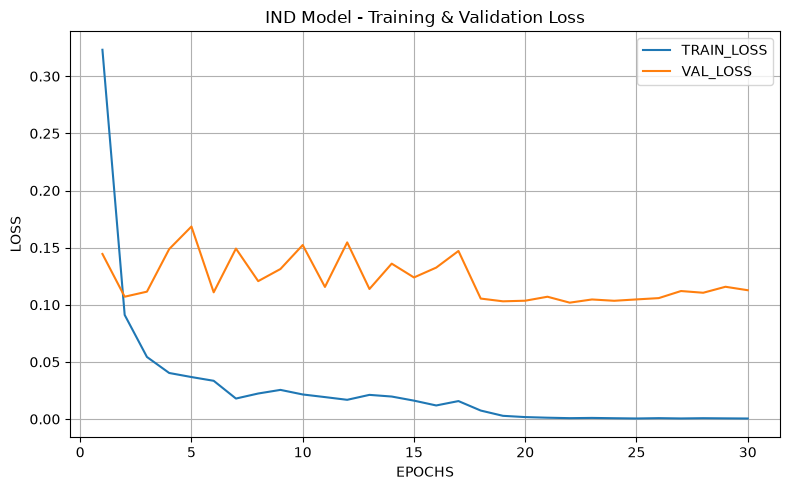

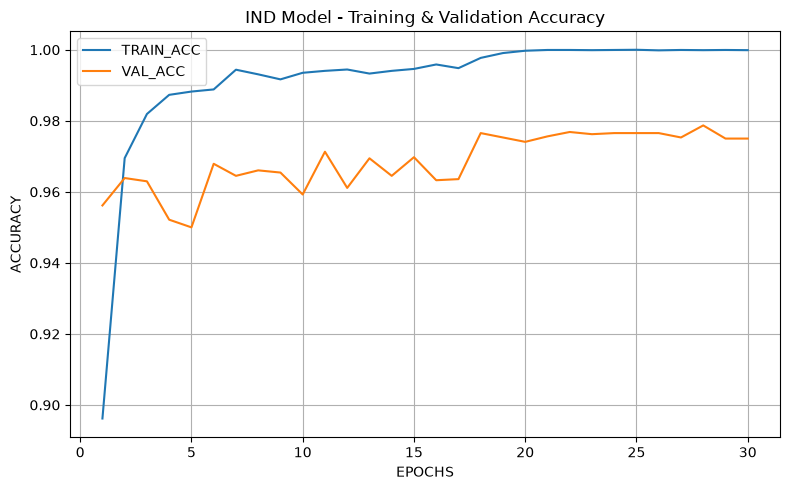

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.978704         0.978769      0.976883  0.977716
                      precision    recall  f1-score      support
AnnualCrop             0.973510  0.980000  0.976744   600.000000
Forest                 0.978793  1.000000  0.989283   600.000000
HerbaceousVegetation   0.953226  0.985000  0.968852   600.000000
Highway                0.987680  0.962000  0.974671   500.000000
Industrial             0.982036  0.984000  0.983017   500.000000
Pasture                0.971939  0.952500  0.962121   400.000000
PermanentCrop          0.966667  0.928000  0.946939   500.000000
Residential            0.981908  0.995000  0.988411   600.000000
River                  0.991935  0.984000  0.987952   500.000000
SeaLake                1.000000  0.998333  0.999166   600.000000
accuracy               0.978704  0.978704  0.978704     0.978704
macro avg              0.978769  0.976883  0.977716  5400.0000

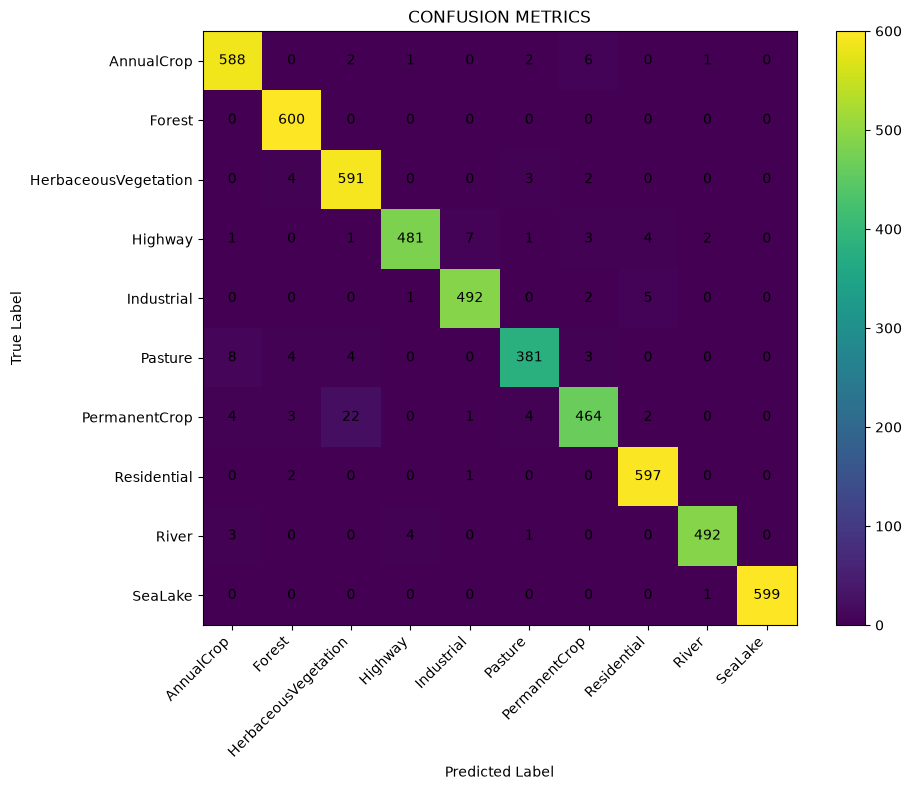

In [8]:
plot_all_evaluation(history, model, test_ind_loader, 'ind')